In [1]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import artm
from artm import BatchVectorizer

In [2]:
train_df = pd.read_parquet('train.parquet', engine='fastparquet')
test_df = pd.read_parquet('test.parquet', engine='fastparquet')

train_df

,text,summary,topic,url,title,date
0,Сладострастник в течение трех лет преследовал ...,Старший преподаватель института коммунального ...,incident,https://www.mk.ru/incident/article/2010/01/05/...,Педофил преследовал подростка три года,06/01/2010
1,Буквально за час до боя курантов в подземном п...,Манежная площадь Москвы стала местом последнег...,incident,https://www.mk.ru/incident/article/2010/01/05/...,Таджики устроили резню на Манежной площади под...,06/01/2010
2,"Там они покатались на лыжах и снегоходах, пооб...",Президент РФ Дмитрий Медведев с семьей проводи...,politics,https://www.mk.ru/politics/article/2010/01/05/...,"""""""За все платит президент""""""",06/01/2010
3,Сосед расстрелял соседа из-за претензий по пов...,Первое убийство в 2010 году произошло в Москве...,incident,https://www.mk.ru/incident/article/2010/01/05/...,Первое убийство года спровоцировал потоп,06/01/2010
4,Причиной трагедии специалисты считают нарушени...,"Шесть человек, в том числе 9-летний ребенок, з...",incident,https://www.mk.ru/incident/article/2010/01/05/...,Целая семья не пережила газовой атаки,06/01/2010
...,...,...,...,...,...,...
25551,"— Георгий Евгеньевич, складывается впечатление...",Они чувствуют себя чужими в мире взрослых и тя...,social,https://www.mk.ru/social/2013/03/19/828147-kak...,Как не стать педофилом?,20/03/2013
25552,"Открывая заседание, президент ассоциации Валер...",К такому выводу пришли представители малых и с...,mosobl,https://www.mk.ru/mosobl/2013/03/19/828148-ray...,Райсовет — на обочине,20/03/2013
25553,На улице Марины Цветаевой и на соседней Спарта...,Власти Подмосковья в лице врио губернатора Анд...,mosobl,https://www.mk.ru/mosobl/2013/03/19/828197-po-...,По закону против джунглей,20/03/2013
25554,Что не нравится жителям города? В последние го...,В Клину строительство высотки в исторической ч...,mosobl,https://www.mk.ru/mosobl/2013/03/19/828203-mes...,Местный батюшка получил место в торговых рядах,20/03/2013


In [3]:
text_column = 'text'

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-zа-яё\s]', ' ', text)
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('russian'))
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [word for word in tokens if len(word) > 2]
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

train_df['processed_text'] = train_df[text_column].apply(preprocess_text)
test_df['processed_text'] = test_df[text_column].apply(preprocess_text)
train_df = train_df[train_df['processed_text'].str.len() > 0]
test_df = test_df[test_df['processed_text'].str.len() > 0]

train_df

,text,summary,topic,url,title,date,processed_text
0,Сладострастник в течение трех лет преследовал ...,Старший преподаватель института коммунального ...,incident,https://www.mk.ru/incident/article/2010/01/05/...,Педофил преследовал подростка три года,06/01/2010,сладострастник течение трех лет преследовал по...
1,Буквально за час до боя курантов в подземном п...,Манежная площадь Москвы стала местом последнег...,incident,https://www.mk.ru/incident/article/2010/01/05/...,Таджики устроили резню на Манежной площади под...,06/01/2010,буквально час боя курантов подземном переходе ...
2,"Там они покатались на лыжах и снегоходах, пооб...",Президент РФ Дмитрий Медведев с семьей проводи...,politics,https://www.mk.ru/politics/article/2010/01/05/...,"""""""За все платит президент""""""",06/01/2010,покатались лыжах снегоходах пообщались другими...
3,Сосед расстрелял соседа из-за претензий по пов...,Первое убийство в 2010 году произошло в Москве...,incident,https://www.mk.ru/incident/article/2010/01/05/...,Первое убийство года спровоцировал потоп,06/01/2010,сосед расстрелял соседа претензий поводу затоп...
4,Причиной трагедии специалисты считают нарушени...,"Шесть человек, в том числе 9-летний ребенок, з...",incident,https://www.mk.ru/incident/article/2010/01/05/...,Целая семья не пережила газовой атаки,06/01/2010,причиной трагедии специалисты считают нарушени...
...,...,...,...,...,...,...,...
25551,"— Георгий Евгеньевич, складывается впечатление...",Они чувствуют себя чужими в мире взрослых и тя...,social,https://www.mk.ru/social/2013/03/19/828147-kak...,Как не стать педофилом?,20/03/2013,георгий евгеньевич складывается впечатление ро...
25552,"Открывая заседание, президент ассоциации Валер...",К такому выводу пришли представители малых и с...,mosobl,https://www.mk.ru/mosobl/2013/03/19/828148-ray...,Райсовет — на обочине,20/03/2013,открывая заседание президент ассоциации валери...
25553,На улице Марины Цветаевой и на соседней Спарта...,Власти Подмосковья в лице врио губернатора Анд...,mosobl,https://www.mk.ru/mosobl/2013/03/19/828197-po-...,По закону против джунглей,20/03/2013,улице марины цветаевой соседней спартаковской ...
25554,Что не нравится жителям города? В последние го...,В Клину строительство высотки в исторической ч...,mosobl,https://www.mk.ru/mosobl/2013/03/19/828203-mes...,Местный батюшка получил место в торговых рядах,20/03/2013,нравится жителям города последние годы древний...


In [6]:
vectorizer = CountVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9
)

train_matrix = vectorizer.fit_transform(train_df['processed_text'])
test_matrix = vectorizer.transform(test_df['processed_text'])
vocabulary = vectorizer.get_feature_names_out()
train_n_wd = train_matrix.T.todense()
test_n_wd = test_matrix.T.todense()

In [7]:
vocabulary = vectorizer.get_feature_names_out()
print(f"Всего терминов: {len(vocabulary)}")
print("Первые 50 терминов:", vocabulary[:50])

Всего терминов: 20000
Первые 50 терминов: ['award' 'boeing' 'com' 'facebook' 'iii' 'instagram' 'international'
 'mercedes' 'new' 'new york' 'open' 'org' 'pussy' 'pussy riot' 'riot' 'sm'
 'ssj' 'stoloto' 'telegram' 'the' 'time' 'twitter' 'value' 'var' 'vip'
 'wikipedia' 'wikipedia org' 'www' 'xix' 'xix века' 'xvi' 'xvii' 'xviii'
 'xxi' 'xxi века' 'xxi веке' 'york' 'youtube' 'абитуриентов' 'абрамович'
 'абрамовича' 'абсолютная' 'абсолютно' 'абсолютное' 'абсолютной'
 'абсолютный' 'абсурд' 'абсурда' 'абу' 'абхазии']


In [8]:
train_batch_vectorizer = BatchVectorizer(
    data_format='bow_n_wd',
    n_wd=train_n_wd,
    vocabulary=vocabulary,
    target_folder='train_batches'
)

c:\Users\izgor\AppData\Local\Programs\Python\Python310\lib\site-packages\bigartm10-0.10.1-py3.10.egg\artm\batches_utils.py:227: DeprecationWarning: Please import `spmatrix` from the `scipy.sparse` namespace; the `scipy.sparse.base` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.sparse.base import spmatrix


In [9]:
test_batch_vectorizer = BatchVectorizer(
    data_format='bow_n_wd',
    n_wd=test_n_wd,
    vocabulary=vocabulary,
    target_folder='test_batches'
)

In [10]:
num_topics_options = [300, 350, 400, 450, 500]
lda_models = {}
perplexities = {}

for num_topics in num_topics_options:
    lda = artm.LDA(
        num_topics=num_topics,
        alpha=0.1,
        beta=0.1,
        num_document_passes=5,
        dictionary=train_batch_vectorizer.dictionary,
        cache_theta=True,
        num_processors=18
    )
    lda.fit_offline(train_batch_vectorizer, num_collection_passes=15)
    lda_models[num_topics] = lda
    perplexities[num_topics] = lda.perplexity_last_value

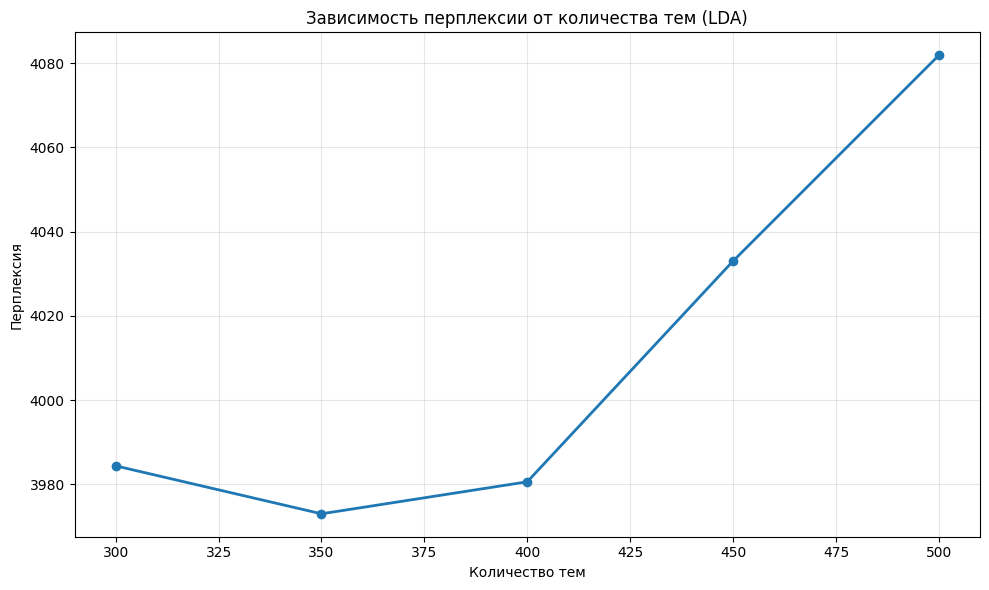

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(list(perplexities.keys()), list(perplexities.values()), marker='o', linewidth=2)
plt.xlabel('Количество тем')
plt.ylabel('Перплексия')
plt.title('Зависимость перплексии от количества тем (LDA)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
def analyze_topics(model, batch, top_words=10):
    theta = model.transform(batch)

    if hasattr(model, "get_phi"):
        phi = model.get_phi()
    else:
        phi = model.phi_
        
    num_topics = len(phi.columns)
    num_rows, _ = theta.shape

    if num_rows == num_topics:
        theta = theta.T

    topic_descriptions = {}
    for topic in phi.columns:
        top_tokens = (
            phi[topic]
            .sort_values(ascending=False)
            .head(top_words)
            .index
            .tolist()
        )
        topic_descriptions[topic] = top_tokens

    dominant_topic = theta.idxmax(axis=1)
    dominant_weight = theta.max(axis=1)

    result = theta.copy()
    result["dominant_topic"] = dominant_topic
    result["dominant_weight"] = dominant_weight

    return result, topic_descriptions

In [70]:
best_num_topics = min(perplexities, key=perplexities.get)
best_lda = lda_models[best_num_topics]

In [ ]:
lda_results, lda_topics = analyze_topics(best_lda, test_batch_vectorizer)
lda_results

,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,...,topic_342,topic_343,topic_344,topic_345,topic_346,topic_347,topic_348,topic_349,dominant_topic,dominant_weight
0,0.004306,0.000374,0.001094,0.000431,0.002018,0.003813,0.000401,0.000931,0.000929,0.000615,...,0.000643,0.000941,0.001025,0.000606,0.002093,0.007373,0.002068,0.001554,topic_73,0.153730
1,0.000818,0.000532,0.000857,0.001834,0.000936,0.002502,0.007441,0.001522,0.001324,0.049781,...,0.002755,0.001725,0.001111,0.001177,0.007618,0.000577,0.000751,0.001186,topic_216,0.202620
2,0.002749,0.000656,0.000614,0.001029,0.000681,0.001348,0.000792,0.000548,0.000861,0.000614,...,0.000603,0.000569,0.000512,0.000632,0.000933,0.002456,0.000884,0.000761,topic_63,0.224462
3,0.001548,0.003323,0.001019,0.000567,0.000673,0.001262,0.000944,0.000862,0.000775,0.002185,...,0.000965,0.002734,0.006003,0.000530,0.001104,0.007915,0.002415,0.001041,topic_105,0.122013
4,0.001037,0.000372,0.007088,0.000856,0.002330,0.000518,0.025783,0.000530,0.001059,0.027360,...,0.002655,0.002345,0.001795,0.000381,0.001581,0.000390,0.000895,0.002125,topic_38,0.160546
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
752,0.001566,0.000790,0.000713,0.000690,0.000658,0.001115,0.001129,0.000866,0.001013,0.001063,...,0.002195,0.001035,0.003191,0.001477,0.000914,0.000701,0.001269,0.001010,topic_209,0.310197
753,0.000854,0.000232,0.000345,0.000223,0.000471,0.000371,0.000394,0.000377,0.000325,0.000347,...,0.000267,0.000542,0.003034,0.000305,0.000528,0.000301,0.000561,0.000748,topic_296,0.321798
754,0.003460,0.015030,0.000716,0.000719,0.000530,0.000731,0.000521,0.000598,0.000660,0.000582,...,0.000914,0.000704,0.001801,0.001057,0.009043,0.001333,0.003575,0.001859,topic_19,0.090801
755,0.000676,0.000379,0.000458,0.000321,0.000425,0.000880,0.000343,0.000861,0.000338,0.000411,...,0.000406,0.001400,0.001362,0.000268,0.000472,0.001710,0.001765,0.000794,topic_36,0.103854


In [72]:
lda_topics

{'topic_0': [('@default_class', 'это'),
  ('@default_class', 'вдв'),
  ('@default_class', 'время'),
  ('@default_class', 'человек'),
  ('@default_class', 'которые'),
  ('@default_class', 'очень'),
  ('@default_class', 'специального'),
  ('@default_class', 'примеру'),
  ('@default_class', 'могут'),
  ('@default_class', 'таких')],
 'topic_1': [('@default_class', 'войны'),
  ('@default_class', 'великой'),
  ('@default_class', 'отечественной'),
  ('@default_class', 'победы'),
  ('@default_class', 'мая'),
  ('@default_class', 'ветеранов'),
  ('@default_class', 'великой отечественной'),
  ('@default_class', 'отечественной войны'),
  ('@default_class', 'войне'),
  ('@default_class', 'памяти')],
 'topic_2': [('@default_class', 'канал'),
  ('@default_class', 'telegram'),
  ('@default_class', 'лучшее'),
  ('@default_class', 'подпишитесь'),
  ('@default_class', 'подпишитесь наш'),
  ('@default_class', 'короткой'),
  ('@default_class', 'наш'),
  ('@default_class', 'вечерней'),
  ('@default_class',

In [73]:
optimal_topics = min(perplexities, key=perplexities.get)
best_lda = lda_models[optimal_topics]
test_theta = best_lda.transform(test_batch_vectorizer)
test_perplexity = best_lda.perplexity_last_value

test_perplexity

3973.00537109375

In [74]:
regularized_model = artm.ARTM(
    num_topics=optimal_topics,
    num_document_passes=5,
    reuse_theta=True,
    num_processors=18
)

regularized_model.regularizers.add(
    artm.SmoothSparsePhiRegularizer(name='sparsity_phi', tau=-0.1)
)
regularized_model.regularizers.add(
    artm.TopicSelectionThetaRegularizer(name='sparsity_theta', tau=-0.5)
)
regularized_model.regularizers.add(
    artm.DecorrelatorPhiRegularizer(name='decorrelator_phi', tau=1e5)
)

regularized_model.scores.add(artm.PerplexityScore(name='perplexity_score'))
regularized_model.scores.add(artm.TopTokensScore(name='top_tokens_score'))

regularized_model.initialize(dictionary=train_batch_vectorizer.dictionary)

In [75]:
regularized_model.fit_offline(train_batch_vectorizer, num_collection_passes=15)

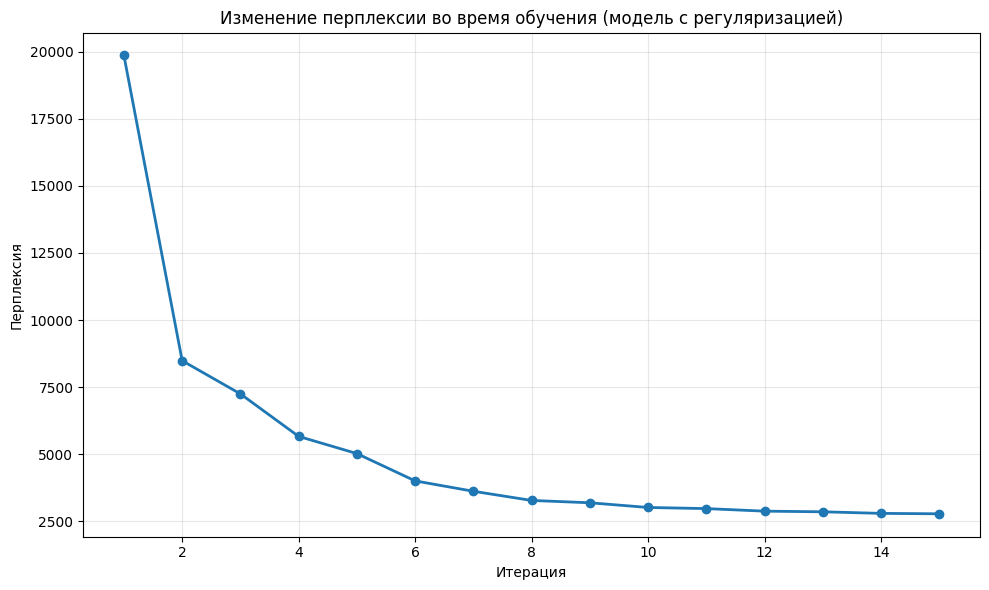

In [76]:
perplexity_values = regularized_model.score_tracker['perplexity_score'].value
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(perplexity_values) + 1), perplexity_values, marker='o', linewidth=2)
plt.xlabel('Итерация')
plt.ylabel('Перплексия')
plt.title('Изменение перплексии во время обучения (модель с регуляризацией)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [77]:
artm_results, artm_topics = analyze_topics(regularized_model, test_batch_vectorizer)
artm_results

,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,...,topic_342,topic_343,topic_344,topic_345,topic_346,topic_347,topic_348,topic_349,dominant_topic,dominant_weight
0,1.845727e-02,6.839252e-07,0.003333,1.273728e-05,8.728327e-03,0.000214,1.400737e-05,0.000344,1.377301e-04,1.735033e-03,...,2.533203e-06,1.325138e-04,1.808184e-05,2.104851e-05,0.009038,1.162143e-03,0.004340,0.000367,topic_73,0.120583
1,6.913354e-05,2.754214e-04,0.000028,4.988510e-05,8.242465e-05,0.000445,9.878875e-04,0.000850,1.899491e-04,5.281777e-02,...,7.508022e-04,3.620035e-03,1.527183e-03,2.824066e-03,0.000331,1.164842e-06,0.001008,0.002663,topic_216,0.205570
2,2.818739e-03,1.025303e-04,0.000118,4.801764e-04,2.959701e-05,0.001081,3.450648e-04,0.000002,3.170217e-04,1.075909e-06,...,6.993288e-06,1.641965e-07,3.904632e-08,1.410209e-05,0.007412,1.867494e-04,0.000056,0.000018,topic_63,0.221189
3,8.230124e-05,6.561831e-06,0.000015,9.184694e-07,1.550163e-08,0.000016,2.366781e-05,0.000094,1.195723e-06,2.540293e-04,...,4.617580e-04,2.352674e-04,3.075586e-02,3.399372e-08,0.000001,1.216337e-02,0.037788,0.000476,topic_108,0.174782
4,5.952016e-04,6.571795e-06,0.006233,5.451633e-05,3.109623e-03,0.000027,5.498033e-02,0.000125,6.254762e-04,1.457500e-02,...,2.442967e-03,2.877067e-03,1.806890e-04,1.627772e-04,0.000573,2.299165e-07,0.000639,0.003030,topic_38,0.068081
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
752,2.793017e-04,3.174998e-06,0.000008,3.324519e-07,3.120894e-06,0.000023,5.168236e-04,0.000001,2.391223e-04,3.290746e-05,...,3.166636e-04,2.131257e-03,1.684832e-01,6.143808e-06,0.000014,3.646268e-07,0.000003,0.000084,topic_344,0.168483
753,4.604186e-04,4.327228e-06,0.000015,3.457954e-07,1.740932e-05,0.000031,3.093166e-06,0.000084,1.207586e-05,3.552505e-05,...,4.309437e-05,2.574715e-04,1.497360e-03,9.674240e-06,0.000073,1.302940e-06,0.000097,0.000142,topic_185,0.214500
754,4.133988e-03,1.057882e-02,0.000111,1.717239e-04,7.552287e-06,0.000243,2.128374e-05,0.000014,5.572602e-04,1.834914e-03,...,4.078036e-03,1.467463e-04,9.420281e-04,5.108508e-05,0.000130,1.705822e-05,0.000994,0.001391,topic_19,0.073176
755,6.746047e-07,1.350920e-06,0.000007,5.729332e-04,1.871184e-06,0.000349,1.691190e-07,0.000112,5.502219e-07,3.195173e-07,...,9.330110e-07,2.219665e-03,8.163702e-04,5.823002e-06,0.000015,6.885526e-05,0.005752,0.000684,topic_41,0.069163


In [78]:
artm_topics

{'topic_0': [('@default_class', 'служить'),
  ('@default_class', 'аппарат'),
  ('@default_class', 'образцы'),
  ('@default_class', 'специального'),
  ('@default_class', 'вдв'),
  ('@default_class', 'образец'),
  ('@default_class', 'системы'),
  ('@default_class', 'касается'),
  ('@default_class', 'назначения'),
  ('@default_class', 'систем')],
 'topic_1': [('@default_class', 'войны'),
  ('@default_class', 'великой'),
  ('@default_class', 'отечественной'),
  ('@default_class', 'великой отечественной'),
  ('@default_class', 'победы'),
  ('@default_class', 'красной'),
  ('@default_class', 'отечественной войны'),
  ('@default_class', 'военных'),
  ('@default_class', 'войне'),
  ('@default_class', 'красной площади')],
 'topic_2': [('@default_class', 'канал'),
  ('@default_class', 'лекарств'),
  ('@default_class', 'лекарства'),
  ('@default_class', 'препараты'),
  ('@default_class', 'telegram'),
  ('@default_class', 'препаратов'),
  ('@default_class', 'подпишитесь'),
  ('@default_class', 'по

In [79]:
train_perplexity = regularized_model.score_tracker['perplexity_score'].last_value
train_perplexity

2778.93359375

In [80]:
test_theta = regularized_model.transform(test_batch_vectorizer)

test_perplexity = regularized_model.get_score('perplexity_score').value
test_perplexity

3186.8486328125

In [81]:
test_perplexity - train_perplexity

407.9150390625